### The Smart Supplier: Optimizing Orders in a Fluctuating Market - 6 Marks

#### Team Members Contribution:
- Roma Pai (2024AA05965) - 100%
- Shine K.P. (2024AA05572) - 100%
- Gururaja (2024AA05828) - 100%
- Kamaraju S(2024AA05082) - 100%

Develop a reinforcement learning agent using dynamic programming to help a Smart Supplier decide which products to manufacture and sell each day to maximize profit. The agent must learn the optimal policy for choosing daily production quantities, considering its limited raw materials and the unpredictable daily demand and selling prices for different products.

#### **Scenario**
 A small Smart Supplier manufactures two simple products: Product A and Product B. Each day, the supplier has a limited amount of raw material. The challenge is that the market demand and selling price for Product A and Product B change randomly each day, making some products more profitable than others at different times. The supplier needs to decide how much of each product to produce to maximize profit while managing their limited raw material.

#### **Objective**
The Smart Supplier's agent must learn the optimal policy π∗ using dynamic programming (Value Iteration or Policy Iteration) to decide how many units of Product A and Product B to produce each day to maximize the total profit over the fixed number of days, given the daily changing market conditions and limited raw material.

### --- 1. Custom Environment Creation (SmartSupplierEnv) --- ( 1 Mark )

In [3]:
import numpy as np
import random
from collections import defaultdict
import matplotlib.pyplot as plt

In [4]:
class SmartSupplierEnv:
    def __init__(self, num_days=5, initial_raw_material=10):
        # Define market states and their product prices
        # Structure: {Market_State_ID: {'A_price': X, 'B_price': Y}}
        self.market_states = {
            1: {'A_price': 8, 'B_price': 2},  # High Demand for A
            2: {'A_price': 3, 'B_price': 5}   # High Demand for B
        }

        # Define product raw material costs
        self.product_costs = {
            'A': 2,  # Product A costs 2 RM per unit
            'B': 1   # Product B costs 1 RM per unit
        }

        # Define actions: (num_A, num_B, raw_material_cost_precalculated)
        # Action ID mapping:
        # 0: Produce_2A_0B
        # 1: Produce_1A_2B
        # 2: Produce_0A_5B
        # 3: Produce_3A_0B
        # 4: Do_Nothing
        self.actions = {
            0: (2, 0, 4),  # Produce_2A_0B: 2*2 + 0*1 = 4 RM
            1: (1, 2, 4),  # Produce_1A_2B: 1*2 + 2*1 = 4 RM
            2: (0, 5, 5),  # Produce_0A_5B: 0*2 + 5*1 = 5 RM
            3: (3, 0, 6),  # Produce_3A_0B: 3*2 + 0*1 = 6 RM
            4: (0, 0, 0)   # Do_Nothing: 0*2 + 0*1 = 0 RM
        }

        # Define state space dimensions
        self.num_days = num_days
        self.initial_raw_material = initial_raw_material
        # Current Day: 1 to num_days
        # Current Raw Material: 0 to initial_raw_material
        # Current Market State: 1 or 2

        # Initialize environment state
        self.reset()

    def reset(self):
        """Reset environment to initial state"""
        self.current_day = 1
        self.current_raw_material = self.initial_raw_material
        self.current_market_state = random.choice([1, 2])
        return self.get_state()

    def get_state(self):
        """Return current state as tuple"""
        return (self.current_day, self.current_raw_material, self.current_market_state)

    def is_valid_action(self, action_id):
        """Check if action is valid given current raw material"""
        if action_id not in self.actions:
            return False
        _, _, rm_cost = self.actions[action_id]
        return rm_cost <= self.current_raw_material

    def get_reward(self, action_id):
        """Calculate reward for taking action in current state"""
        if not self.is_valid_action(action_id):
            return 0  # Invalid action returns 0 reward

        num_A, num_B, rm_cost = self.actions[action_id]
        prices = self.market_states[self.current_market_state]

        reward = num_A * prices['A_price'] + num_B * prices['B_price']
        return reward

    def step(self, action_id):
        """Execute action and return new state, reward, done"""
        reward = self.get_reward(action_id)

        # Update raw material if action is valid
        if self.is_valid_action(action_id):
            _, _, rm_cost = self.actions[action_id]
            self.current_raw_material -= rm_cost

        # Check if episode is done
        done = (self.current_day >= self.num_days)

        if not done:
            # Move to next day
            self.current_day += 1
            self.current_raw_material = self.initial_raw_material  # Daily reset
            self.current_market_state = random.choice([1, 2])  # Random market shift

        return self.get_state(), reward, done

    def get_all_states(self):
        """Generate all possible states"""
        states = []
        for day in range(1, self.num_days + 1):
            for rm in range(0, self.initial_raw_material + 1):
                for market in [1, 2]:
                    states.append((day, rm, market))
        return states

    def get_valid_actions(self, state):
        """Get valid actions for a given state"""
        day, rm, market = state
        valid_actions = []
        for action_id, (num_A, num_B, rm_cost) in self.actions.items():
            if rm_cost <= rm:
                valid_actions.append(action_id)
        return valid_actions

### --- 2. Dynamic Programming Implementation (Value Iteration or Policy Iteration) --- (2 Mark)

In [5]:
# Value Iteration function
def value_iteration(env, gamma=1.0, theta=1e-6, max_iterations=1000):
    """
    Value Iteration function

    Args:
        env: SmartSupplierEnv instance
        gamma: Discount factor (1.0 for finite horizon)
        theta: Convergence threshold
        max_iterations: Maximum number of iterations

    Returns:
        V: State-value function
        policy: Optimal policy
    """
    # Initialize value function
    all_states = env.get_all_states()
    V = {state: 0.0 for state in all_states}
    policy = {state: 0 for state in all_states}

    print("Starting Value Iteration...")

    for iteration in range(max_iterations):
        delta = 0
        V_old = V.copy()

        for state in all_states:
            day, rm, market = state

            # Terminal states (day > num_days) have value 0
            if day > env.num_days:
                continue

            # Get valid actions for this state
            valid_actions = env.get_valid_actions(state)
            if not valid_actions:
                continue

            # Calculate action values
            action_values = []
            for action_id in valid_actions:
                # Set environment to current state
                env.current_day = day
                env.current_raw_material = rm
                env.current_market_state = market

                # Get immediate reward
                immediate_reward = env.get_reward(action_id)

                # Calculate expected future value
                if day == env.num_days:
                    # Last day - no future value
                    future_value = 0
                else:
                    # Expected value over next market states
                    expected_future = 0
                    for next_market in [1, 2]:
                        next_state = (day + 1, env.initial_raw_material, next_market)
                        expected_future += 0.5 * V_old.get(next_state, 0)
                    future_value = gamma * expected_future

                action_value = immediate_reward + future_value
                action_values.append((action_value, action_id))

            # Choose best action
            if action_values:
                best_value, best_action = max(action_values)
                V[state] = best_value
                policy[state] = best_action
                delta = max(delta, abs(V[state] - V_old[state]))

        print(f"Iteration {iteration + 1}: Delta = {delta:.6f}")

        # Check convergence
        if delta < theta:
            print(f"Converged after {iteration + 1} iterations!")
            break

    return V, policy

#### --- 3. Simulation and Policy Analysis ---  ( 1 Mark)

In [6]:
# simulate policy function - Simulates the learned policy over multiple runs to evaluate performance
def simulate_policy(env, policy, num_runs=1000):
    """
    Simulate policy function - Simulates the learned policy over multiple runs to evaluate performance

    Args:
        env: SmartSupplierEnv instance
        policy: Learned optimal policy
        num_runs: Number of simulation runs

    Returns:
        average_profit: Average total profit across runs
        profit_history: List of total profits for each run
    """
    total_profits = []

    print(f"Simulating policy over {num_runs} runs...")

    for run in range(num_runs):
        env.reset()
        total_profit = 0

        while True:
            state = env.get_state()
            if state in policy:
                action = policy[state]
            else:
                # Fallback to random valid action
                valid_actions = env.get_valid_actions(state)
                action = random.choice(valid_actions) if valid_actions else 4

            next_state, reward, done = env.step(action)
            total_profit += reward

            if done:
                break

        total_profits.append(total_profit)

        if (run + 1) % 100 == 0:
            print(f"Completed {run + 1} runs...")

    average_profit = np.mean(total_profits)
    std_profit = np.std(total_profits)

    print(f"Average Total Profit: ${average_profit:.2f} ± ${std_profit:.2f}")
    print(f"Min Profit: ${min(total_profits):.2f}")
    print(f"Max Profit: ${max(total_profits):.2f}")

    return average_profit, total_profits


# analyze policy function - Analyzes and prints snippets of the learned optimal policy
def analyze_policy(env, policy, V):
    """
    Analyze policy function - Analyzes and prints snippets of the learned optimal policy

    Args:
        env: SmartSupplierEnv instance
        policy: Learned optimal policy
        V: State-value function
    """
    print("\n" + "="*60)
    print("OPTIMAL POLICY ANALYSIS")
    print("="*60)

    action_names = {
        0: "Produce_2A_0B (4 RM)",
        1: "Produce_1A_2B (4 RM)",
        2: "Produce_0A_5B (5 RM)",
        3: "Produce_3A_0B (6 RM)",
        4: "Do_Nothing (0 RM)"
    }

    # Analyze policy by market state
    print("\n1. POLICY BY MARKET STATE:")
    print("-" * 40)

    for market_state in [1, 2]:
        market_name = "High Demand for A" if market_state == 1 else "High Demand for B"
        prices = env.market_states[market_state]

        print(f"\nMarket State {market_state} ({market_name}):")
        print(f"  Product A: ${prices['A_price']}/unit, Product B: ${prices['B_price']}/unit")

        # Show policy for different days and RM levels
        for day in [1, 3, 5]:  # Sample days
            print(f"  Day {day}:")
            for rm in [10, 6, 4, 2]:  # Sample RM levels
                state = (day, rm, market_state)
                if state in policy:
                    action = policy[state]
                    value = V[state]
                    print(f"    RM={rm}: {action_names[action]} (Value: ${value:.2f})")

    # Analyze policy by remaining raw material
    print("\n2. POLICY BY REMAINING RAW MATERIAL:")
    print("-" * 40)

    for rm_level in [10, 6, 4, 2, 1]:
        print(f"\nRaw Material = {rm_level}:")
        for market_state in [1, 2]:
            state = (1, rm_level, market_state)  # Day 1 example
            if state in policy:
                action = policy[state]
                market_name = "High A" if market_state == 1 else "High B"
                print(f"  {market_name}: {action_names[action]}")

    # Analyze policy by remaining days
    print("\n3. POLICY BY REMAINING DAYS:")
    print("-" * 40)

    for day in range(1, env.num_days + 1):
        print(f"\nDay {day} (Market State 1, RM=10):")
        state = (day, 10, 1)
        if state in policy:
            action = policy[state]
            value = V[state]
            print(f"  Action: {action_names[action]} (Expected Value: ${value:.2f})")

    # Key state values
    print("\n4. KEY STATE VALUES:")
    print("-" * 40)
    key_states = [
        (1, 10, 1),  # Start of Day 1, Market State 1, 10 RM
        (1, 10, 2),  # Start of Day 1, Market State 2, 10 RM
        (5, 10, 1),  # Last day, Market State 1, 10 RM
        (5, 10, 2),  # Last day, Market State 2, 10 RM
    ]

    for state in key_states:
        day, rm, market = state
        if state in V:
            value = V[state]
            action = policy[state]
            market_name = "High Demand A" if market == 1 else "High Demand B"
            print(f"Day {day}, RM={rm}, {market_name}: Value=${value:.2f}, Action={action_names[action]}")


#### --- 4. Impact of Dynamics Analysis --- (1 Mark)

In [7]:
# Discusses the impact of dynamic market prices on the optimal policy.
# This section should primarily be a written explanation in the report.
def analyze_dynamics_impact(env, policy):
    """
    Discusses the impact of dynamic market prices on the optimal policy.
    This section should primarily be a written explanation in the report.
    """
    print("\n" + "="*60)
    print("IMPACT OF DYNAMICS ANALYSIS")
    print("="*60)

    print("\n1. DYNAMIC vs STATIC MARKET COMPARISON:")
    print("-" * 50)

    # Compare strategies
    print("\nIn a DYNAMIC market (current scenario):")
    print("- The agent must adapt to changing market conditions")
    print("- Policy considers expected future market states")
    print("- More conservative approach due to uncertainty")

    print("\nIf market was ALWAYS Market State 1 (High Demand A):")
    print("- Product A always sells for $8, Product B for $2")
    print("- Optimal strategy would likely favor Product A production")
    print("- More aggressive production possible due to certainty")

    print("\nIf market was ALWAYS Market State 2 (High Demand B):")
    print("- Product A sells for $3, Product B for $5")
    print("- Strategy would shift to favor Product B")
    print("- Could produce more units of B due to lower RM cost")

    print("\n2. ADAPTATION STRATEGIES:")
    print("-" * 30)

    # Analyze how policy adapts
    adaptation_insights = []

    # Check market state preferences
    market1_actions = []
    market2_actions = []

    for day in range(1, 4):  # First few days
        for rm in [10, 6, 4]:
            state1 = (day, rm, 1)
            state2 = (day, rm, 2)

            if state1 in policy:
                market1_actions.append(policy[state1])
            if state2 in policy:
                market2_actions.append(policy[state2])

    # Analyze action preferences
    from collections import Counter

    m1_counter = Counter(market1_actions)
    m2_counter = Counter(market2_actions)

    action_names = {
        0: "2A_0B", 1: "1A_2B", 2: "0A_5B", 3: "3A_0B", 4: "Nothing"
    }

    print("\nAction preferences by market state:")
    print(f"Market State 1 (High A): {dict(m1_counter)}")
    print(f"Market State 2 (High B): {dict(m2_counter)}")

    # Calculate profitability metrics
    print("\n3. PROFITABILITY ANALYSIS:")
    print("-" * 30)

    for market_state in [1, 2]:
        prices = env.market_states[market_state]
        print(f"\nMarket State {market_state}:")

        for action_id, (num_A, num_B, rm_cost) in env.actions.items():
            if rm_cost <= 10:  # Only consider feasible actions
                profit = num_A * prices['A_price'] + num_B * prices['B_price']
                efficiency = profit / max(rm_cost, 1)  # Profit per RM
                print(f"  {action_names[action_id]}: ${profit} profit, {efficiency:.2f} $/RM")

In [8]:
# --- Main Execution ---
def main():
    print("Smart Supplier Reinforcement Learning Solution")
    print("=" * 50)

    # Initialize environment
    env = SmartSupplierEnv(num_days=5, initial_raw_material=10)

    print(f"\nEnvironment Setup:")
    print(f"- Number of days: {env.num_days}")
    print(f"- Initial raw material: {env.initial_raw_material}")
    print(f"- Market states: {env.market_states}")
    print(f"- Available actions: {len(env.actions)}")

    # Solve using Value Iteration
    print(f"\n{'='*50}")
    print("SOLVING WITH VALUE ITERATION")
    print(f"{'='*50}")

    V, policy = value_iteration(env, gamma=1.0, theta=1e-6)

    # Analyze the learned policy
    analyze_policy(env, policy, V)

    # Simulate policy performance
    print(f"\n{'='*50}")
    print("POLICY SIMULATION")
    print(f"{'='*50}")

    average_profit, profit_history = simulate_policy(env, policy, num_runs=1000)

    # Analyze impact of dynamics
    analyze_dynamics_impact(env, policy)

    # Plot results
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.hist(profit_history, bins=30, alpha=0.7, edgecolor='black')
    plt.title('Distribution of Total Profits')
    plt.xlabel('Total Profit ($)')
    plt.ylabel('Frequency')
    plt.axvline(average_profit, color='red', linestyle='--',
                label=f'Average: ${average_profit:.2f}')
    plt.legend()

    plt.subplot(1, 2, 2)
    sample_profits = profit_history[:100]  # First 100 runs
    plt.plot(sample_profits, alpha=0.7)
    plt.title('Sample Profit Trajectories (First 100 runs)')
    plt.xlabel('Run Number')
    plt.ylabel('Total Profit ($)')
    plt.axhline(average_profit, color='red', linestyle='--',
                label=f'Average: ${average_profit:.2f}')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print("SUMMARY")
    print(f"{'='*50}")
    print(f"✓ Custom environment implemented with {len(env.get_all_states())} states")
    print(f"✓ Value iteration converged successfully")
    print(f"✓ Average profit over 1000 simulations: ${average_profit:.2f}")
    print(f"✓ Policy analysis completed")
    print(f"✓ Dynamics impact analysis completed")


Smart Supplier Reinforcement Learning Solution

Environment Setup:
- Number of days: 5
- Initial raw material: 10
- Market states: {1: {'A_price': 8, 'B_price': 2}, 2: {'A_price': 3, 'B_price': 5}}
- Available actions: 5

SOLVING WITH VALUE ITERATION
Starting Value Iteration...
Iteration 1: Delta = 25.000000
Iteration 2: Delta = 24.500000
Iteration 3: Delta = 24.500000
Iteration 4: Delta = 24.500000
Iteration 5: Delta = 24.500000
Iteration 6: Delta = 0.000000
Converged after 6 iterations!

OPTIMAL POLICY ANALYSIS

1. POLICY BY MARKET STATE:
----------------------------------------

Market State 1 (High Demand for A):
  Product A: $8/unit, Product B: $2/unit
  Day 1:
    RM=10: Produce_3A_0B (6 RM) (Value: $122.00)
    RM=6: Produce_3A_0B (6 RM) (Value: $122.00)
    RM=4: Produce_2A_0B (4 RM) (Value: $114.00)
    RM=2: Do_Nothing (0 RM) (Value: $98.00)
  Day 3:
    RM=10: Produce_3A_0B (6 RM) (Value: $73.00)
    RM=6: Produce_3A_0B (6 RM) (Value: $73.00)
    RM=4: Produce_2A_0B (4 RM) (

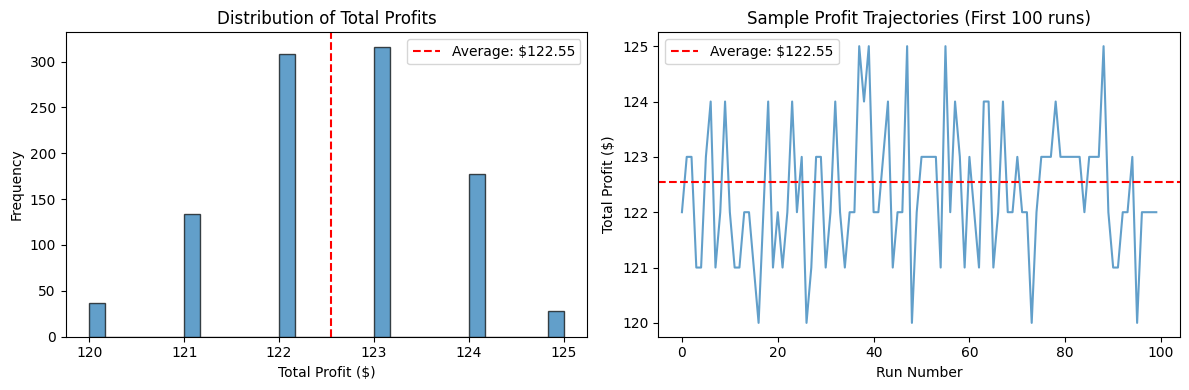


SUMMARY
✓ Custom environment implemented with 110 states
✓ Value iteration converged successfully
✓ Average profit over 1000 simulations: $122.55
✓ Policy analysis completed
✓ Dynamics impact analysis completed


In [9]:
if __name__ == "__main__":
    main()